In [2]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [35]:
import numpy as np
import tensorflow as tf
import random
import pandas as pd
from PIL import Image
import seaborn as sns
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from data.data import load_dataset
import evaluate


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

In [5]:
random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [6]:
X, y, X_test, y_test  = load_dataset(model = 'efficientnetb0')  
X , X_test = effnet_preprocess(X) , effnet_preprocess(X_test)   

Loading cached dataset from data/dataset_rgb.npz...


In [7]:
print(f'X shape:{X.shape}, y shape:{y.shape}, X_test shape:{X_test.shape}')

X shape:(5600, 224, 224, 3), y shape:(5600,), X_test shape:(1600, 224, 224, 3)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((4480, 224, 224, 3), (4480,), (1120, 224, 224, 3), (1120,))

In [9]:
base_model = EfficientNetB0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224,224,3)
)

base_model.trainable = False

W0000 00:00:1786475252.142754   28421 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1786475252.144321   28421 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3500 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [10]:
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(4, activation = 'softmax')(x)

effNet = Model(inputs = base_model.input, outputs = out)

In [11]:
effNet.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [13]:
def data_generator(X, y, batch_size):
    n = len(X)
    while True:
        idx = np.random.permutation(n)
        for i in range(0, n, batch_size):
            batch_idx = idx[i:i+batch_size]
            yield X[batch_idx], y[batch_idx]

train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_train.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_train.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_val.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_val.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

history = effNet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=len(X_train)//8,
    validation_steps=len(X_val)//8
)

Epoch 1/10


/home/rynoko/projects/MRI-GPU/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786475253.905781   28421 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1786475259.902476   28745 service.cc:153] XLA service 0x75110c034a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786475259.902497   28745 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786475260.119230   28745 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00

 11/560 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3295 - loss: 1.4385   

I0000 00:00:1786475274.917636   28745 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


560/560 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.7607 - loss: 0.6701 - val_accuracy: 0.8420 - val_loss: 0.4221
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8571 - loss: 0.3989 - val_accuracy: 0.8687 - val_loss: 0.3532
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8850 - loss: 0.3334 - val_accuracy: 0.8804 - val_loss: 0.3228
Epoch 4/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8933 - loss: 0.3008 - val_accuracy: 0.8946 - val_loss: 0.2930
Epoch 5/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9047 - loss: 0.2779 - val_accuracy: 0.9000 - val_loss: 0.2769
Epoch 6/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9033 - loss: 0.2576 - val_accuracy: 0.9000 - val_loss: 0.2643
Epoch 7/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9167 - loss: 0.2318 - val_accuracy: 0.9054 - val_loss: 0.2451
Epoch 8/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9248 - loss: 0.2195 - val_accuracy: 0.90

In [14]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

frozen_layers = 0
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
        frozen_layers += 1

effNet.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_train.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_train.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_val.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_val.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

history_1 = effNet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    steps_per_epoch=len(X_train) // 8,
    validation_steps=len(X_val) // 8,
    callbacks=[early_stop]
)

# Evaluate 
test_ds = tf.data.Dataset.from_generator(
    lambda: data_generator(X_test, y_test, batch_size=8),
    output_signature=(
        tf.TensorSpec(shape=(None, *X_test.shape[1:]), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *y_test.shape[1:]), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

test_loss, test_acc = effNet.evaluate(test_ds, steps=len(X_test) // 8)

Epoch 1/15


I0000 00:00:1786475356.393452   28746 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62200__.251


560/560 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9382 - loss: 0.1707 - val_accuracy: 0.9143 - val_loss: 0.2130
Epoch 2/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9475 - loss: 0.1487 - val_accuracy: 0.9268 - val_loss: 0.1927
Epoch 3/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9516 - loss: 0.1340 - val_accuracy: 0.9304 - val_loss: 0.1767
Epoch 4/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9592 - loss: 0.1242 - val_accuracy: 0.9250 - val_loss: 0.1741
Epoch 5/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9594 - loss: 0.1170 - val_accuracy: 0.9375 - val_loss: 0.1573
Epoch 6/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9645 - loss: 0.1063 - val_accuracy: 0.9429 - val_loss: 0.1538
Epoch 7/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9676 - loss: 0.0968 - val_accuracy: 0.9366 - val_loss: 0.1540
Epoch 8/15
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9685 - loss: 0.0917 - val_accuracy: 0.95

In [15]:
print(f'Accuracy: {test_acc:.2f}, Loss: {test_loss:.2f}')

Accuracy: 0.93, Loss: 0.40


In [16]:
CLASS_NAMES = ["notumor", "glioma", "meningioma", "pituitary"]

W0000 00:00:1786475462.338331   28421 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
W0000 00:00:1786475463.383760   28421 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.
E0000 00:00:1786475467.855688   28747 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786475469.890089   28747 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786475471.350234   28747 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step
Classification Report:
               precision    recall  f1-score   support

     notumor     0.9190    0.9925    0.9543       400
      glioma     0.9628    0.7775    0.8603       400
  meningioma     0.8565    0.9400    0.8963       400
   pituitary     0.9729    0.9875    0.9801       400

    accuracy                         0.9244      1600
   macro avg     0.9278    0.9244    0.9228      1600
weighted avg     0.9278    0.9244    0.9228      1600



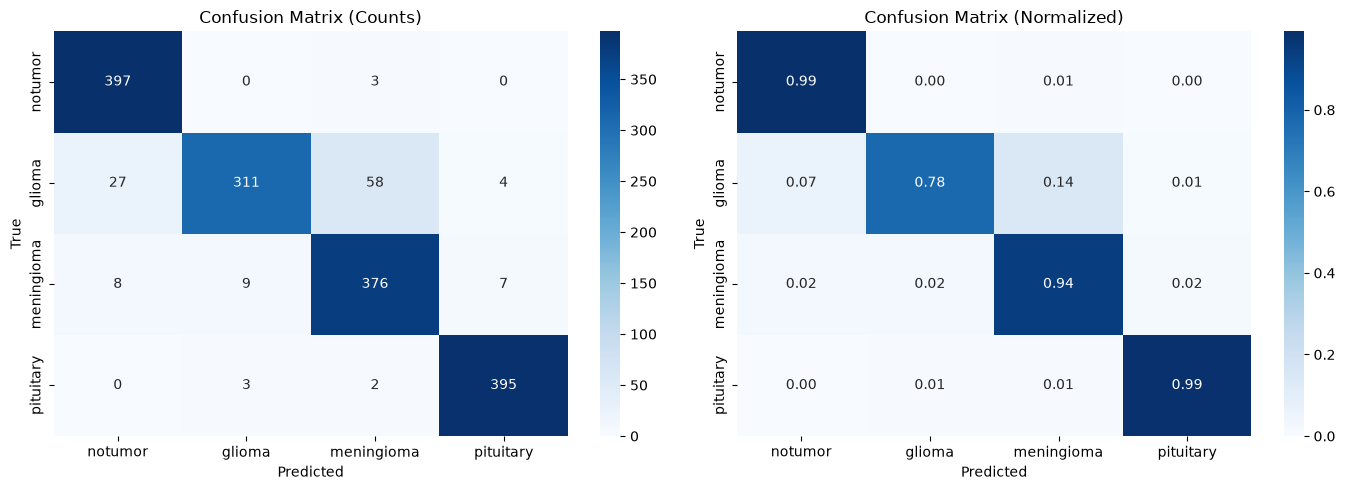

Macro-averaged AUC (OvR): 0.9807


W0000 00:00:1786475477.865895   28421 cpu_allocator_impl.cc:82] Allocation of 674365440 exceeds 10% of free system memory.
W0000 00:00:1786475478.528581   28421 cpu_allocator_impl.cc:82] Allocation of 674365440 exceeds 10% of free system memory.


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


W0000 00:00:1786475480.366335   28421 cpu_allocator_impl.cc:82] Allocation of 963379200 exceeds 10% of free system memory.


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
notumor - val precision: 0.9614, test precision: 0.9190
glioma - val precision: 0.9498, test precision: 0.9628
meningioma - val precision: 0.9154, test precision: 0.8565
pituitary - val precision: 0.9648, test precision: 0.9729


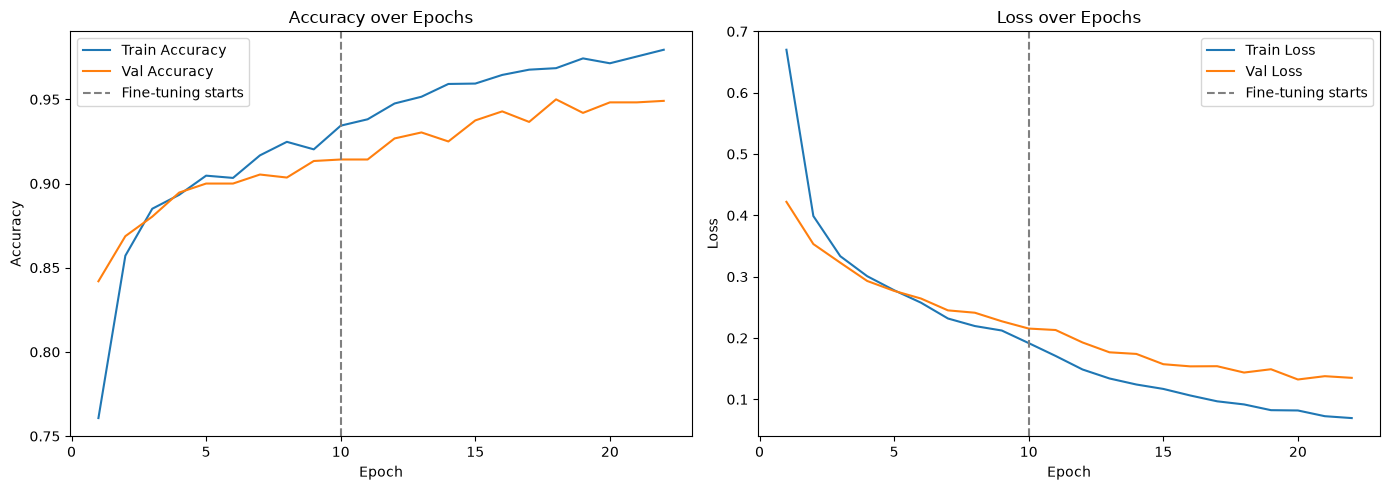

In [ ]:
results = evaluate.evaluate_model(effNet, X_test, y_test, class_names=CLASS_NAMES, save_prefix="efficientnetB0")
evaluate.evaluate_per_class(effNet, X_val, X_test, y_val, y_test, CLASS_NAMES)
evaluate.plot_training_curves(history, history_1, save_prefix="efficientNetBO")

effNet.save("models/efficientNetB0_mri_tumor.keras")

False predictions made in Test set:

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


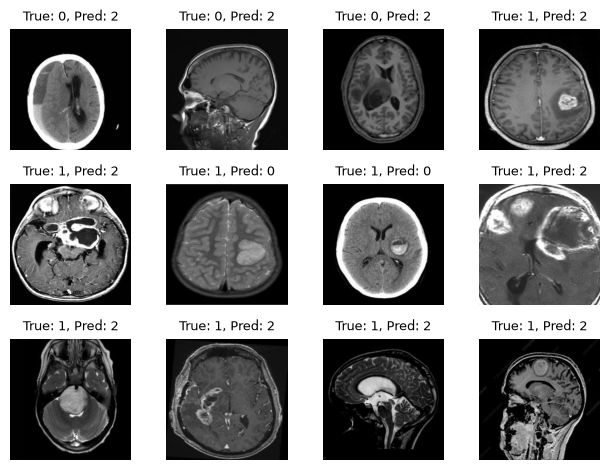


False predictions made in Validation set:

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


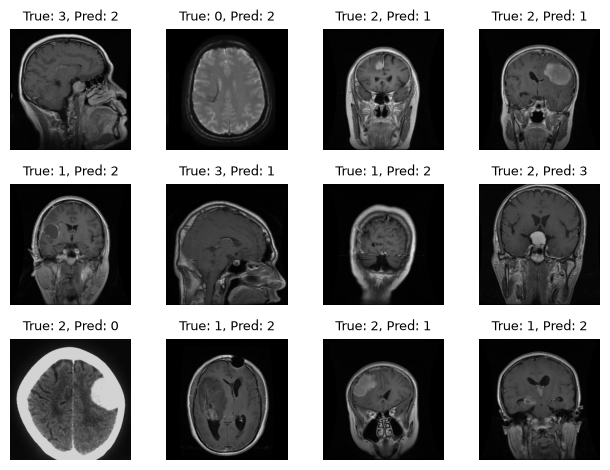

In [18]:
print('False predictions made in Test set:\n')
evaluate.plot_false_preds(effNet,X_test,y_test,'efficientnet')

print('\nFalse predictions made in Validation set:\n')
evaluate.plot_false_preds(effNet,X_val,y_val,'efficientnet')

In [19]:
from keras.models import load_model
model = load_model('models/efficientNetB0_mri_tumor.keras')

[efficientNetB0_mri_tumor] 120 wrong predictions out of 1600 (showing first 12)


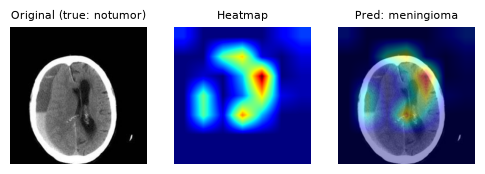

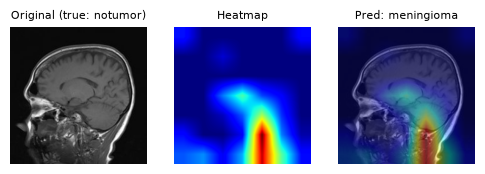

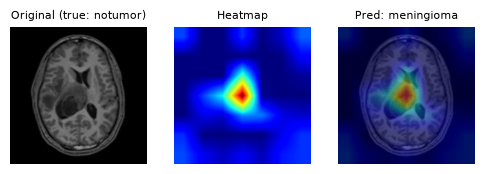

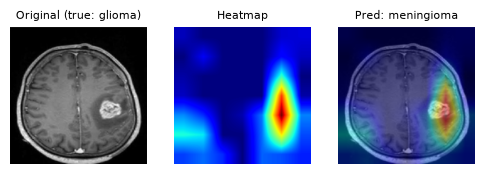

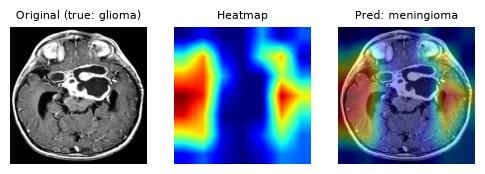

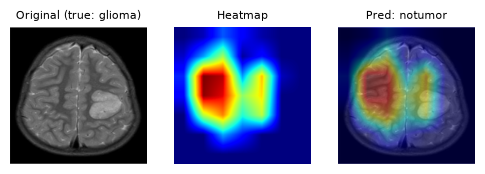

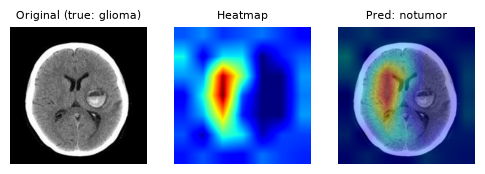

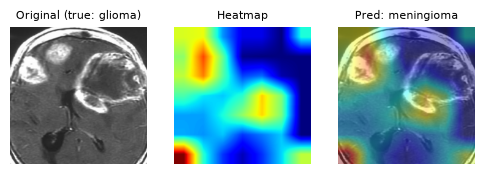

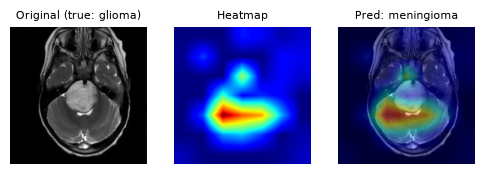

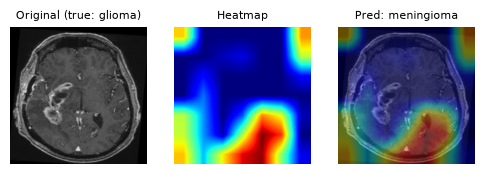

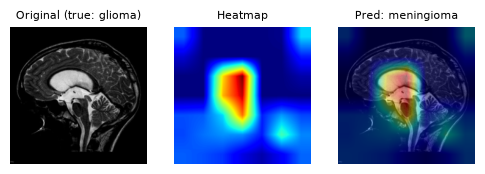

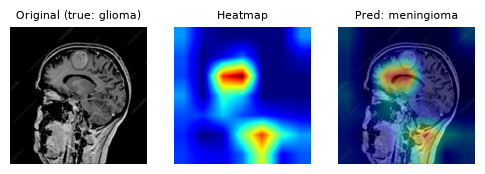

In [ ]:
from gradcam import get_models,run_for_model, prep_grad_model,DATA_FILES,PREPROCESS_FNS
models = get_models()
gradCam_models = {name: prep_grad_model(obj, name) for name, obj in models.items()}
run_for_model("efficientNetB0_mri_tumor", models, gradCam_models,max_examples=12)